# NetworkX — Order & Payment Graph

This notebook models a simple order-payment knowledge graph.  
Alice places an order for an item; the payment is in **pending** state.  
We then query the graph to check whether Alice has completed payment.

In [10]:
import networkx as nx

# Build the knowledge graph
G = nx.DiGraph()

# Customer
G.add_node("Alice", type="Customer")

# Orders with different statuses
G.add_node("Order#101", type="Order", status="placed")
G.add_node("Order#102", type="Order", status="delivered")
G.add_node("Order#103", type="Order", status="pending")
G.add_node("Order#104", type="Order", status="cancelled")

# Items
G.add_node("Laptop", type="Item", price=1200)
G.add_node("Mouse", type="Item", price=40)
G.add_node("Keyboard", type="Item", price=80)
G.add_node("Monitor", type="Item", price=300)

# Payments with different statuses
G.add_node("Payment#1", type="Payment", status="pending")
G.add_node("Payment#2", type="Payment", status="success")
G.add_node("Payment#3", type="Payment", status="failed")
G.add_node("Payment#4", type="Payment", status="refunded")

# Edges (relationships)
G.add_edge("Alice", "Order#101", relation="placed_order")
G.add_edge("Alice", "Order#102", relation="placed_order")
G.add_edge("Alice", "Order#103", relation="placed_order")
G.add_edge("Alice", "Order#104", relation="placed_order")

G.add_edge("Order#101", "Laptop", relation="contains_item")
G.add_edge("Order#102", "Mouse", relation="contains_item")
G.add_edge("Order#103", "Keyboard", relation="contains_item")
G.add_edge("Order#104", "Monitor", relation="contains_item")

G.add_edge("Order#101", "Payment#1", relation="has_payment")
G.add_edge("Order#102", "Payment#2", relation="has_payment")
G.add_edge("Order#103", "Payment#3", relation="has_payment")
G.add_edge("Order#104", "Payment#4", relation="has_payment")

print("=== Graph Overview ===")
print("Nodes:")
for node, attrs in G.nodes(data=True):
    print(f"  {node}: {attrs}")

print("\nEdges:")
for src, tgt, data in G.edges(data=True):
    print(f"  {src} -[{data['relation']}]-> {tgt}")

=== Graph Overview ===
Nodes:
  Alice: {'type': 'Customer'}
  Order#101: {'type': 'Order', 'status': 'placed'}
  Order#102: {'type': 'Order', 'status': 'delivered'}
  Order#103: {'type': 'Order', 'status': 'pending'}
  Order#104: {'type': 'Order', 'status': 'cancelled'}
  Laptop: {'type': 'Item', 'price': 1200}
  Mouse: {'type': 'Item', 'price': 40}
  Keyboard: {'type': 'Item', 'price': 80}
  Monitor: {'type': 'Item', 'price': 300}
  Payment#1: {'type': 'Payment', 'status': 'pending'}
  Payment#2: {'type': 'Payment', 'status': 'success'}
  Payment#3: {'type': 'Payment', 'status': 'failed'}
  Payment#4: {'type': 'Payment', 'status': 'refunded'}

Edges:
  Alice -[placed_order]-> Order#101
  Alice -[placed_order]-> Order#102
  Alice -[placed_order]-> Order#103
  Alice -[placed_order]-> Order#104
  Order#101 -[contains_item]-> Laptop
  Order#101 -[has_payment]-> Payment#1
  Order#102 -[contains_item]-> Mouse
  Order#102 -[has_payment]-> Payment#2
  Order#103 -[contains_item]-> Keyboard
  O

In [24]:
# Tool-bound query helpers for order and payment tracking
from langchain.tools import tool

@tool
def search_database(query: str, limit: int = 10) -> str:
    """Search the customer database for records matching the query.

    Args:
        query: Search terms to look for.
        limit: Maximum number of results to return.
    """
    return f"Found {limit} results for '{query}'"


def _get_orders_by_customer_impl(graph, customer, show_count=False, num_orders=None):
    """Implementation: return orders placed by a customer."""
    if customer not in graph:
        print(f"Customer '{customer}' not found.")
        return []

    orders = []
    for neighbor in graph.successors(customer):
        if graph[customer][neighbor].get("relation") == "placed_order":
            orders.append(neighbor)

    if num_orders is not None:
        if num_orders < 0:
            print("num_orders cannot be negative.")
            return []
        orders = orders[:num_orders]

    if show_count:
        print(f"{customer} has placed {len(orders)} order(s).")

    if orders:
        print(f"Orders by {customer}: {orders}")
    else:
        print(f"No orders found for {customer}.")

    return orders


def _get_order_status_impl(graph, username, order_id):
    """Implementation: return order status if order belongs to user."""
    if username not in graph:
        print(f"Customer '{username}' not found.")
        return None

    if order_id not in graph or graph.nodes[order_id].get("type") != "Order":
        print(f"Order '{order_id}' not found.")
        return None

    if not graph.has_edge(username, order_id) or graph[username][order_id].get("relation") != "placed_order":
        print(f"Order '{order_id}' is not associated with user '{username}'.")
        return None

    status = graph.nodes[order_id].get("status", "unknown")
    print(f"Order {order_id} status for {username}: {status}")
    return status


def _get_payment_status_by_order_impl(graph, username, order_id):
    """Implementation: return payment status for a user's order."""
    if username not in graph:
        print(f"Customer '{username}' not found.")
        return None

    if order_id not in graph or graph.nodes[order_id].get("type") != "Order":
        print(f"Order '{order_id}' not found.")
        return None

    if not graph.has_edge(username, order_id) or graph[username][order_id].get("relation") != "placed_order":
        print(f"Order '{order_id}' is not associated with user '{username}'.")
        return None

    payment_nodes = []
    for neighbor in graph.successors(order_id):
        if graph[order_id][neighbor].get("relation") == "has_payment":
            payment_nodes.append(neighbor)

    if not payment_nodes:
        print(f"No payment record found for {order_id}.")
        return None

    payment_status = {
        payment_node: graph.nodes[payment_node].get("status", "unknown")
        for payment_node in payment_nodes
    }

    if len(payment_status) == 1:
        single_node = next(iter(payment_status))
        status = payment_status[single_node]
        print(f"Payment status for {order_id} (user: {username}): {status} ({single_node})")
        return status

    print(f"Payment statuses for {order_id} (user: {username}): {payment_status}")
    return payment_status


def run_tool(tool_name, **kwargs):
    """
    Run a tool by name using keyword arguments.

    Args:
        tool_name: Name of the tool in TOOLS.
        **kwargs: Arguments passed to the underlying function.

    Returns:
        Any: Function result.
    """
    if tool_name not in TOOLS:
        print(f"Unknown tool: {tool_name}")
        list_tools()
        return None

    return TOOLS[tool_name]["function"](**kwargs)


@tool
def get_orders_by_customer(graph, customer, show_count=False, num_orders=None):
    """
    Return orders placed by a customer.

    Args:
        graph: NetworkX graph.
        customer: Customer node name.
        show_count: If True, print order count.
        num_orders: Optional max number of orders to return.

    Returns:
        list[str]: Matching order IDs.
    """
    return run_tool(
        "orders_by_customer",
        graph=graph,
        customer=customer,
        show_count=show_count,
        num_orders=num_orders,
    )


@tool
def get_order_status(graph, username, order_id):
    """
    Return order status if the order belongs to the specified user.

    Args:
        graph: NetworkX graph.
        username: Customer node name.
        order_id: Order node ID.

    Returns:
        str | None: Order status when found; otherwise None.
    """
    return run_tool("order_status", graph=graph, username=username, order_id=order_id)


@tool
def get_payment_status_by_order(graph, username, order_id):
    """
    Return payment status for a user's order.

    Args:
        graph: NetworkX graph.
        username: Customer node name.
        order_id: Order node ID.

    Returns:
        str | dict | None: Payment status value(s), or None if missing.
    """
    return run_tool("payment_status", graph=graph, username=username, order_id=order_id)


def list_tools():
    """
    Print available tools and their descriptions.
    """
    for name, config in TOOLS.items():
        print(f"- {name}: {config['description']}")


TOOLS = {
    "orders_by_customer": {
        "function": _get_orders_by_customer_impl,
        "description": "List orders placed by a customer with optional count and limit.",
    },
    "order_status": {
        "function": _get_order_status_impl,
        "description": "Get order status for a specific user and order ID.",
    },
    "payment_status": {
        "function": _get_payment_status_by_order_impl,
        "description": "Get payment status for a specific user's order ID.",
    },
}

print("Available tools:")
list_tools()

Available tools:
- orders_by_customer: List orders placed by a customer with optional count and limit.
- order_status: Get order status for a specific user and order ID.
- payment_status: Get payment status for a specific user's order ID.


C:\Users\veguntur\AppData\Local\Temp\ipykernel_23964\3414720251.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


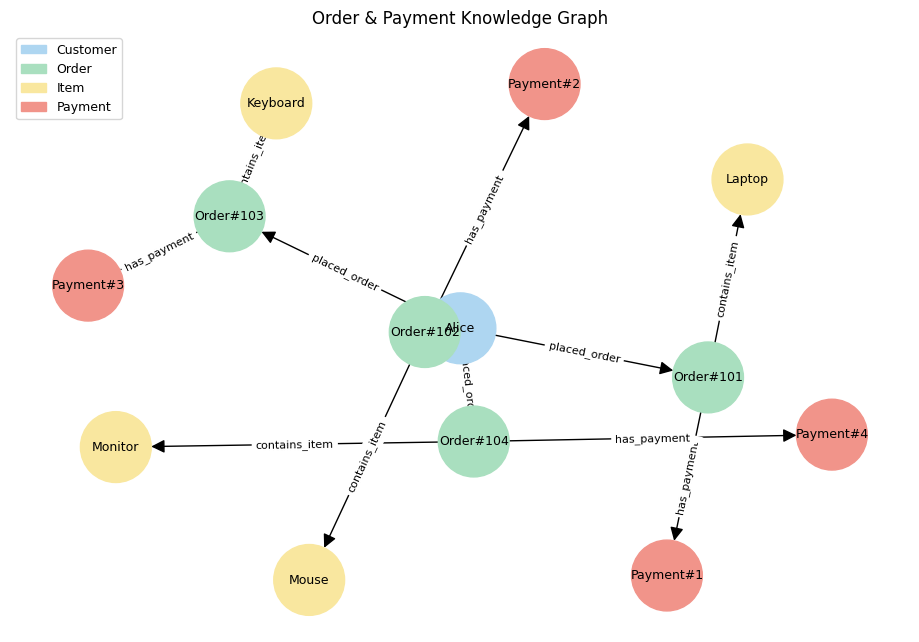

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize_graph(graph):
    """Render the order-payment knowledge graph with node-type colors and labeled relationships."""

    # Color nodes by type
    type_colors = {
        "Customer": "#AED6F1",
        "Order":    "#A9DFBF",
        "Item":     "#F9E79F",
        "Payment":  "#F1948A",
    }
    node_colors = [type_colors[graph.nodes[n]["type"]] for n in graph.nodes()]

    pos = nx.spring_layout(graph, seed=7)
    edge_labels = {(s, t): d["relation"] for s, t, d in graph.edges(data=True)}

    plt.figure(figsize=(9, 6))
    nx.draw(
        graph, pos,
        with_labels=True,
        node_color=node_colors,
        node_size=2600,
        font_size=9,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=20,
    )
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=8)

    legend_patches = [mpatches.Patch(color=c, label=t) for t, c in type_colors.items()]
    plt.legend(handles=legend_patches, loc="upper left", fontsize=9)

    plt.title("Order & Payment Knowledge Graph")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

visualize_graph(G)

In [13]:
from pathlib import Path
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from dotenv import load_dotenv

env_path = Path.cwd() / ".env"
if not env_path.exists():
    env_path = Path.cwd().parent / ".env"
load_dotenv(env_path)  # Load environment variables from workspace root .env file

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    # other params...
)

In [31]:
from langchain_core.prompts import (
    SystemMessagePromptTemplate,
    HumanMessagePromptTemplate,
    ChatPromptTemplate,
)
from langchain.tools import tool

username = "Alice"

# Adapter tools for LLM use (no graph argument in schema).
@tool
def orders_by_customer_tool(customer: str, num_orders: int = 5, show_count: bool = False):
    """Get orders placed by a customer."""
    return run_tool(
        "orders_by_customer",
        graph=G,
        customer=customer,
        num_orders=num_orders,
        show_count=show_count,
    )


@tool
def order_status_tool(username: str, order_id: str):
    """Get order status for a user and order ID."""
    return run_tool("order_status", graph=G, username=username, order_id=order_id)


@tool
def payment_status_tool(username: str, order_id: str):
    """Get payment status for a user and order ID."""
    return run_tool("payment_status", graph=G, username=username, order_id=order_id)


@tool
def list_tools_tool():
    """List available graph tools."""
    list_tools()
    return "Listed available tools."


system = SystemMessagePromptTemplate.from_template(
    "You are a bot that answers questions about this order graph. Use tools when needed."
)
question = HumanMessagePromptTemplate.from_template(
    "What is the payment status of the latest order placed by {username}? Return concise JSON."
)

messages = [system, question]
template = ChatPromptTemplate(messages)
prompt_value = template.invoke({"username": username})

llm_with_tools = llm.bind_tools([
    orders_by_customer_tool,
    order_status_tool,
    payment_status_tool,
    list_tools_tool,
])

response = llm_with_tools.invoke(prompt_value)

had_output = False
if response.content:
    print("Model response:")
    print(response.content)
    had_output = True

if getattr(response, "tool_calls", None):
    print("\nTool calls detected:")
    for call in response.tool_calls:
        name = call.get("name")
        args = dict(call.get("args", {}) or {})
        print(f"- {name}({args})")

        if name == "orders_by_customer_tool":
            result = orders_by_customer_tool.invoke(args)
        elif name == "order_status_tool":
            result = order_status_tool.invoke(args)
        elif name == "payment_status_tool":
            result = payment_status_tool.invoke(args)
        elif name == "list_tools_tool":
            result = list_tools_tool.invoke(args)
        else:
            print(f"Unsupported tool call: {name}")
            result = None

        if result is not None:
            print(f"Result: {result}")
            had_output = True

if not had_output:
    print("No text/tool output. Raw response for debugging:")
    print(response)


Tool calls detected:
- orders_by_customer_tool({'customer': 'Alice', 'num_orders': 1})
Orders by Alice: ['Order#101']
Result: ['Order#101']


In [ ]:
print("Interactive Order Query Console")
print("Type 'exit' anytime to stop.")
print("Type 'help' to list available tools.\n")

while True:
    query_type = input(
        "Choose tool: orders_by_customer | order_status | payment_status | help | exit\n> "
    ).strip().lower()

    if query_type == "exit":
        print("Exiting query console.")
        break

    if query_type == "help":
        list_tools()
        print()
        continue

    if query_type == "orders_by_customer":
        customer = input("Enter customer name: ").strip()
        if customer.lower() == "exit":
            print("Exiting query console.")
            break

        count_arg = input("Show order count? (yes/no): ").strip().lower()
        if count_arg == "exit":
            print("Exiting query console.")
            break

        num_orders_arg = input("How many orders to display? (press Enter for all): ").strip()
        if num_orders_arg.lower() == "exit":
            print("Exiting query console.")
            break

        show_count = count_arg in {"yes", "y", "true", "1"}
        num_orders = int(num_orders_arg) if num_orders_arg else None
        run_tool(
            "orders_by_customer",
            graph=G,
            customer=customer,
            show_count=show_count,
            num_orders=num_orders,
        )
        print()
        continue

    if query_type == "order_status":
        username = input("Enter customer name: ").strip()
        if username.lower() == "exit":
            print("Exiting query console.")
            break

        order_id = input("Enter order id (example: Order#101): ").strip()
        if order_id.lower() == "exit":
            print("Exiting query console.")
            break

        run_tool("order_status", graph=G, username=username, order_id=order_id)
        print()
        continue

    if query_type == "payment_status":
        username = input("Enter customer name: ").strip()
        if username.lower() == "exit":
            print("Exiting query console.")
            break

        order_id = input("Enter order id (example: Order#101): ").strip()
        if order_id.lower() == "exit":
            print("Exiting query console.")
            break

        run_tool("payment_status", graph=G, username=username, order_id=order_id)
        print()
        continue

    print("Invalid tool. Use: orders_by_customer, order_status, payment_status, help, exit.\n")

Interactive Order Query Console
Type 'exit' anytime to stop.

Invalid query type. Please choose one of: orders_by_customer, order_status, payment_status, exit.

Exiting query console.
